# Phase 2: Exploratory Data Analysis & Time-Series Preprocessing
### Steam Player Forecasting Project

**Author:** JoshiMinh  
**Scope:** Phase 2 of the 5-Phase End-to-End Time-Series Forecasting Architecture  
**Dataset:** Cleaned Steam Monthly Player Counts (`data/processed/steam_games_monthly.csv`)  

---

## 1. Executive Summary & Objectives

In **Phase 1**, we ingested, cleaned, and standardized historical monthly player concurrency data across 7 long-term representative Steam titles spanning July 2012 to August 2021 (up to 110 monthly observations per title).

The objective of **Phase 2** is to rigorously analyze the underlying time-series data generating processes and build a modular, leakage-free preprocessing pipeline. Specifically:
1. **Exploratory Data Analysis (EDA):** Understand long-term trends, concurrency dynamics (Peak vs. Average), rolling statistics, and structural breaks (e.g. Free-to-Play transitions, global pandemic surges).
2. **Seasonality & Calendar Effects:** Quantify platform-wide seasonal effects driven by Steam Summer Sales, Winter Sales, and annual esports events (e.g. Dota 2 *The International*).
3. **Decomposition & Stationarity:** Conduct LOESS-based STL decomposition, Augmented Dickey-Fuller (ADF), and KPSS unit-root tests to diagnose non-stationarity and determine required integration orders ($d, D$).
4. **Autocorrelation Analysis:** Compute Autocorrelation Functions (ACF) and Partial Autocorrelation Functions (PACF) to identify autoregressive and moving average signatures.
5. **Leakage-Safe Preprocessing Pipeline:** Implement and validate stateful transformers (Log, Box-Cox, Differencing) and scalers (MinMaxScaler, StandardScaler, RobustScaler) that fit strictly on training windows and invert accurately.
6. **Chronological Splitting:** Establish reproducible chronological partitions ($H=12$ months test holdout, $H=12$ months validation) complying with `configs/default.yaml`.

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Steam Player Forecasting imports
from steam_player_forecasting.data.loader import load_processed_data, get_available_games, load_config
from steam_player_forecasting.features.split import train_val_test_split, split_by_game
from steam_player_forecasting.features.transforms import (
    LogTransformer,
    BoxCoxTransformer,
    DifferencingTransformer,
    difference_series,
    invert_difference_series
)
from steam_player_forecasting.features.scalers import TimeSeriesScaler
from steam_player_forecasting.features.diagnostics import (
    check_stationarity,
    compute_acf_pacf,
    decompose_time_series,
    compute_rolling_stats
)

# Plot styling configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "grid.alpha": 0.6,
})

print("Successfully loaded libraries and modules.")

Successfully loaded libraries and modules.


## 2. Dataset Overview & Selected Titles

We load the consolidated multi-game monthly dataset prepared in Phase 1. Let's inspect the game catalog, temporal spans, and high-level statistics.

In [2]:
df_all = load_processed_data()
print(f"Total processed rows: {len(df_all):,}")
print(f"Columns: {list(df_all.columns)}\n")

# Summary table per game
summary_table = []
for game, g_df in df_all.groupby("Game_Name"):
    g_sorted = g_df.sort_values("Month_Year")
    summary_table.append({
        "Game Title": game,
        "Start Month": g_sorted["Month_Year"].dt.strftime("%Y-%m").iloc[0],
        "End Month": g_sorted["Month_Year"].dt.strftime("%Y-%m").iloc[-1],
        "Total Months": len(g_sorted),
        "Mean Avg Players": int(g_sorted["Avg_players"].mean()),
        "Max Peak Players": int(g_sorted["Peak_Players"].max()),
        "Latest Avg Players": int(g_sorted["Avg_players"].iloc[-1]),
    })

summary_df = pd.DataFrame(summary_table).sort_values(by="Total Months", ascending=False)
display(summary_df)

Total processed rows: 671
Columns: ['Game_Name', 'Month_Year', 'Avg_players', 'Peak_Players', 'Gain', 'Percent_Gain']

                         Game Title Start Month End Month  Total Months  Mean Avg Players  Max Peak Players  Latest Avg Players
0  Counter-Strike: Global Offensive     2012-07   2021-08           110            424113           1250298              632122
1                            Dota 2     2012-07   2021-08           110            348234           1023454              422980
4                   Team Fortress 2     2012-07   2021-08           110             53876            121916               54681
6                          Warframe     2013-03   2021-08           102             39666            110293               52567
3                              Rust     2013-12   2021-08            93             56501            187432               94781
2                Grand Theft Auto V     2015-04   2021-08            77             87329            292436      

## 3. Historical Trajectories & Structural Breaks

A key property of gaming player counts is the presence of **structural breaks** and regime changes caused by external shocks:
1. **Free-to-Play Transitions & Major Updates:** In December 2018, Valve transitioned *Counter-Strike: Global Offensive* to Free-to-Play and launched *Danger Zone*, causing an unprecedented upward trajectory.
2. **COVID-19 Pandemic Lockdowns (March 2020):** Worldwide stay-at-home orders produced a synchronized demand shock across video games, driving CS:GO over 1.3 million peak concurrent players and breaking historical records.
3. **Streaming & Influencer Viral Events (January 2021):** *Rust* experienced a sudden ~2x surge in concurrent player base when popular Twitch streamer servers launched (OfflineTV server).
4. **Platform Giveaways & Major Content Drops:** *Grand Theft Auto V* surged in July 2019 (*Diamond Casino & Resort*) and May 2020 (*Epic Games Store* free giveaway).

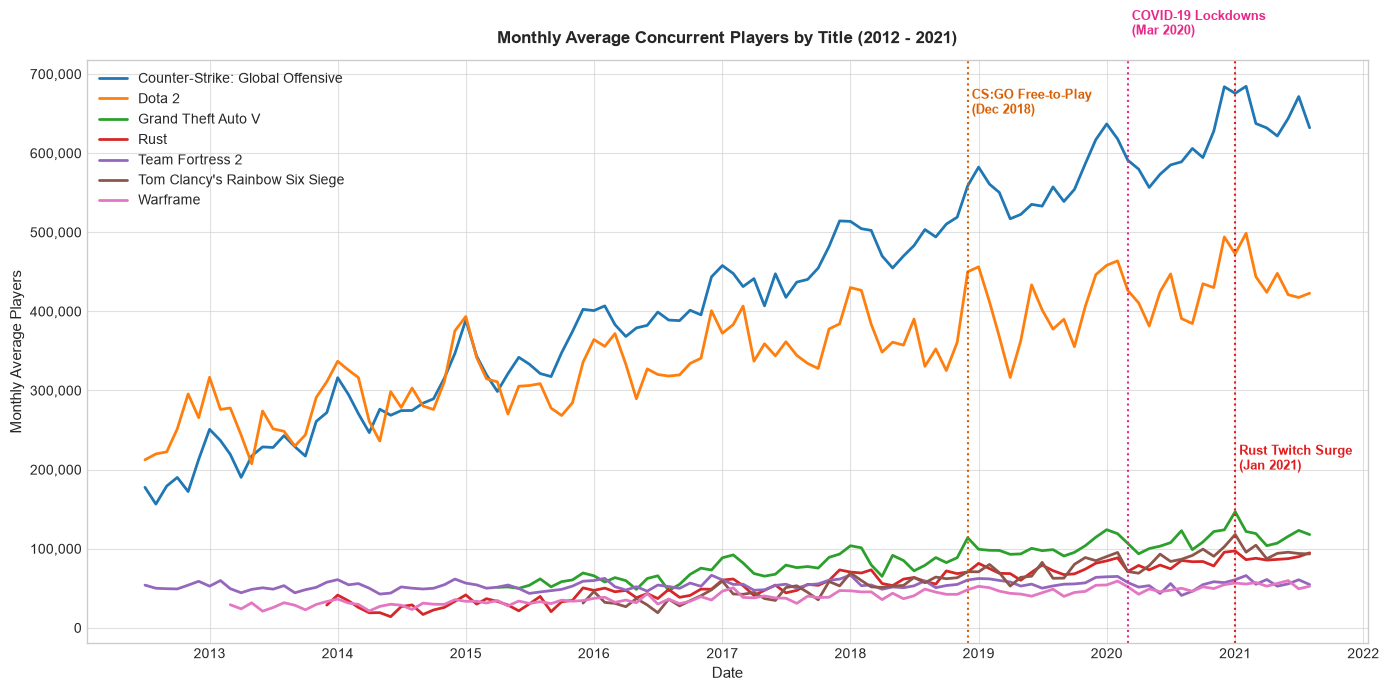

In [3]:
# Plot historical player trajectories across all games
fig, ax = plt.subplots(figsize=(14, 7))

for game, g_df in df_all.groupby("Game_Name"):
    g_sorted = g_df.sort_values("Month_Year")
    ax.plot(g_sorted["Month_Year"], g_sorted["Avg_players"], label=game, linewidth=2.0)

# Structural break annotations
ax.axvline(pd.to_datetime("2018-12-01"), color="#d95f02", linestyle=":", linewidth=1.5)
ax.text(pd.to_datetime("2018-12-01"), 650000, " CS:GO Free-to-Play\n (Dec 2018)", fontsize=9, color="#d95f02", fontweight="bold")

ax.axvline(pd.to_datetime("2020-03-01"), color="#e7298a", linestyle=":", linewidth=1.5)
ax.text(pd.to_datetime("2020-03-01"), 750000, " COVID-19 Lockdowns\n (Mar 2020)", fontsize=9, color="#e7298a", fontweight="bold")

ax.axvline(pd.to_datetime("2021-01-01"), color="#e41a1c", linestyle=":", linewidth=1.5)
ax.text(pd.to_datetime("2021-01-01"), 200000, " Rust Twitch Surge\n (Jan 2021)", fontsize=9, color="#e41a1c", fontweight="bold")

ax.set_title("Monthly Average Concurrent Players by Title (2012 - 2021)", pad=12)
ax.set_ylabel("Monthly Average Players")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 4. Peak vs. Average Player Dynamics

Examining the ratio $\text{Ratio}_t = \frac{\text{Peak\_Players}_t}{\text{Avg\_players}_t}$ provides insight into **concurrency volatility and player concentration**:
- A ratio close to $1.5\text{--}1.8\times$ indicates sustained, global 24/7 engagement across timezones (e.g. *Counter-Strike* and *Dota 2*).
- A ratio of $2.2\text{--}3.0+\times$ indicates high player concentration during weekend events, content drops, or specific regional peaks (e.g. *Warframe*, *GTA V*).

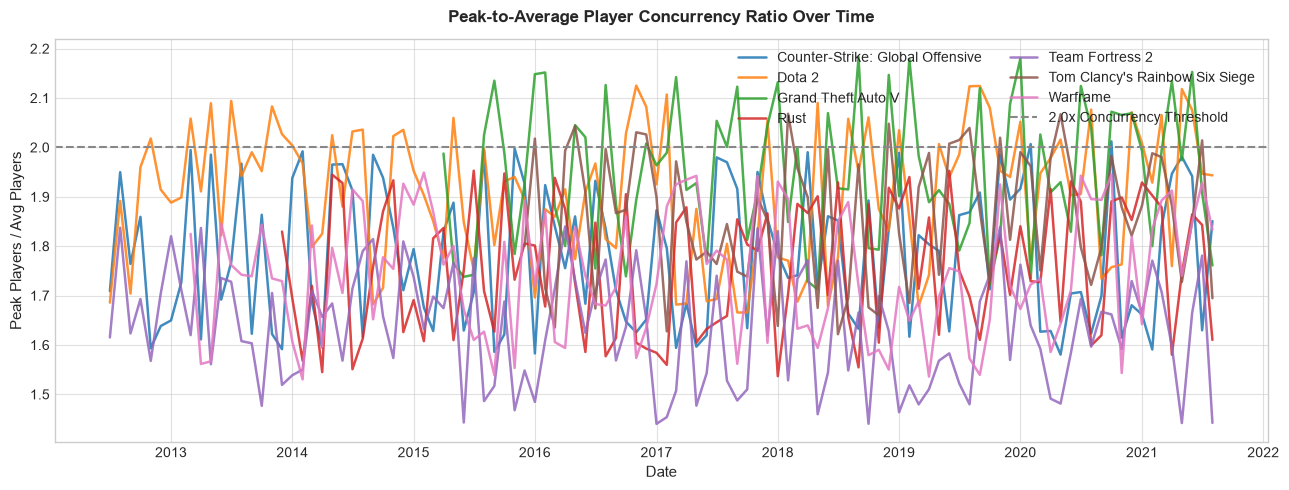

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
for game, g_df in df_all.groupby("Game_Name"):
    g_sorted = g_df.sort_values("Month_Year")
    ratio = g_sorted["Peak_Players"] / g_sorted["Avg_players"]
    ax.plot(g_sorted["Month_Year"], ratio, label=game, linewidth=1.8, alpha=0.85)

ax.axhline(2.0, color="#888888", linestyle="--", label="2.0x Concurrency Threshold")
ax.set_title("Peak-to-Average Player Concurrency Ratio Over Time", pad=12)
ax.set_ylabel("Peak Players / Avg Players")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

## 5. Rolling Statistics & Heteroscedasticity

In time-series modeling, **heteroscedasticity** refers to time-varying variance. For Steam player series, as the mean player level increases, the amplitude of monthly fluctuations also grows proportionally (multiplicative error structure).

We compute 12-month rolling means and rolling standard deviations using `compute_rolling_stats()` to verify whether variance stabilization (e.g. logarithmic or Box-Cox transformations) is necessary.

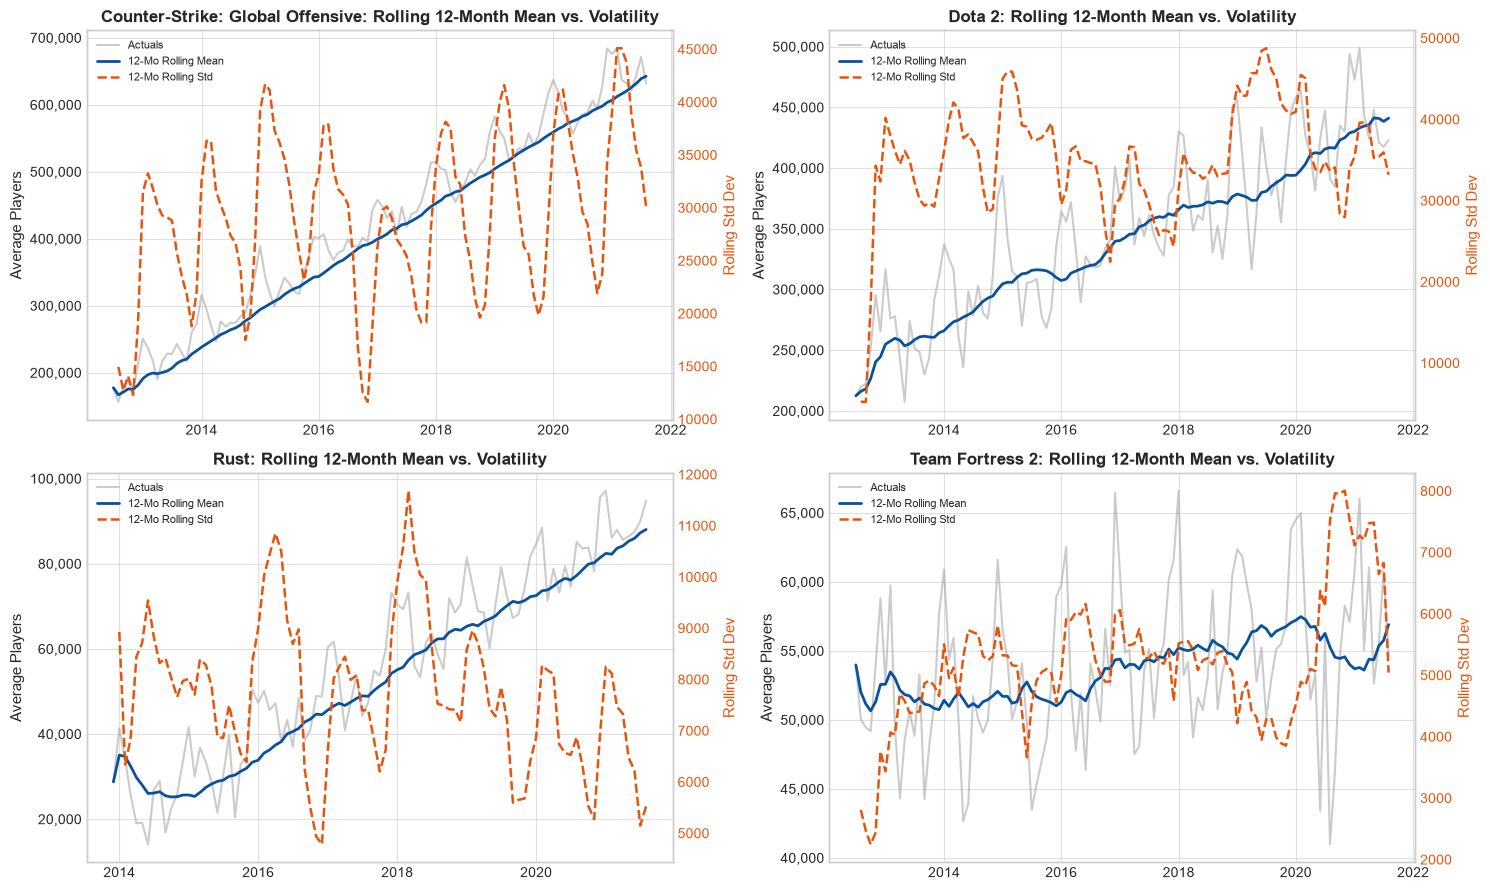

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
sample_titles = ["Counter-Strike: Global Offensive", "Dota 2", "Rust", "Team Fortress 2"]

for idx, game in enumerate(sample_titles):
    ax = axes[idx // 2, idx % 2]
    g_df = df_all[df_all["Game_Name"] == game].sort_values("Month_Year")
    s = pd.Series(g_df["Avg_players"].values, index=g_df["Month_Year"])
    r_df = compute_rolling_stats(s, windows=[12])

    ax.plot(s.index, s.values, label="Actuals", color="#999999", alpha=0.5)
    ax.plot(r_df.index, r_df["rolling_mean_12"], label="12-Mo Rolling Mean", color="#08519c", linewidth=2.0)

    ax_sec = ax.twinx()
    ax_sec.plot(r_df.index, r_df["rolling_std_12"], label="12-Mo Rolling Std", color="#e6550d", linestyle="--", linewidth=1.8)
    ax_sec.set_ylabel("Rolling Std Dev", color="#e6550d")
    ax_sec.tick_params(axis="y", labelcolor="#e6550d")
    ax_sec.grid(False)

    ax.set_title(f"{game}: Rolling 12-Month Mean vs. Volatility")
    ax.set_ylabel("Average Players")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_sec.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Seasonality & Calendar Events

Steam experiences strong annual calendar seasonality:
1. **Steam Summer Sale (June – July):** Massive discounts drive millions of active users and player engagement spikes.
2. **Steam Winter Sale / Holiday Season (December – January):** School holidays and Christmas vacation bring high gaming activity.
3. **Back to School / Fall Dips (September – October):** End of summer vacation and resumption of academic schedules regularly produce seasonal troughs.

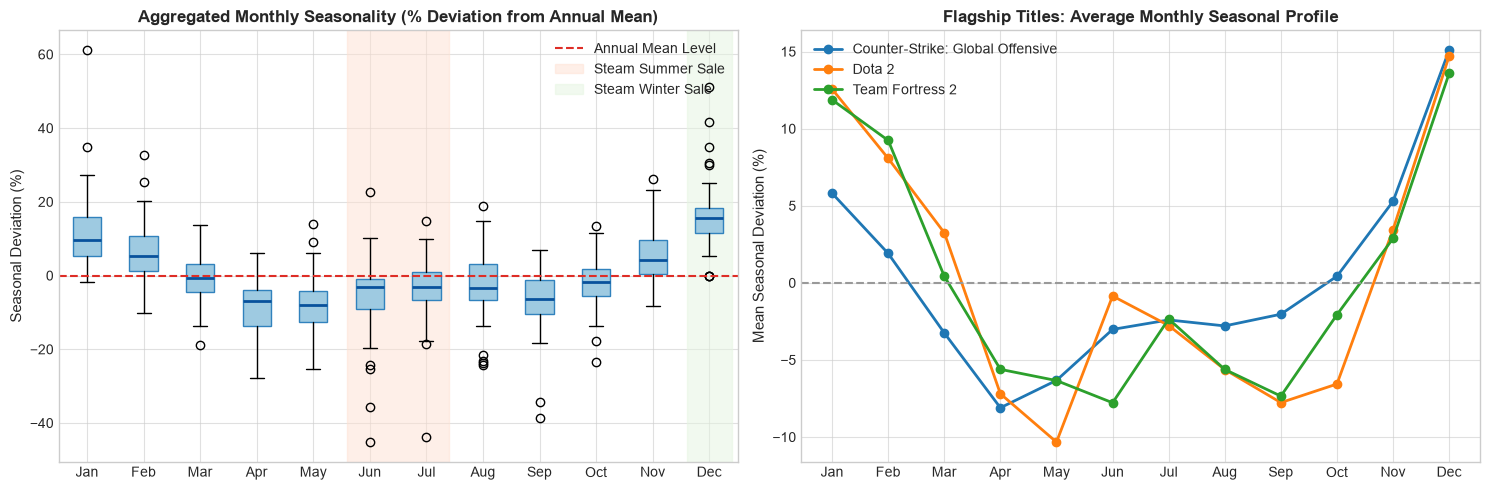

In [6]:
df_season = df_all.copy()
df_season["Month_Num"] = df_season["Month_Year"].dt.month
df_season["Year"] = df_season["Month_Year"].dt.year
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Compute percentage deviation from each game's annual mean
game_year_means = df_season.groupby(["Game_Name", "Year"])["Avg_players"].transform("mean")
df_season["Dev_Pct"] = ((df_season["Avg_players"] - game_year_means) / game_year_means) * 100

month_deviations = [df_season[df_season["Month_Num"] == m]["Dev_Pct"].dropna().values for m in range(1, 13)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
ax1.boxplot(month_deviations, patch_artist=True, tick_labels=month_names,
            boxprops=dict(facecolor="#9ecae1", color="#3182bd"),
            medianprops=dict(color="#08519c", linewidth=2.0))
ax1.axhline(0, color="#de2d26", linestyle="--", label="Annual Mean Level")
ax1.axvspan(6 - 0.4, 7 + 0.4, color="#fee0d2", alpha=0.5, label="Steam Summer Sale")
ax1.axvspan(12 - 0.4, 12 + 0.4, color="#e5f5e0", alpha=0.5, label="Steam Winter Sale")
ax1.set_title("Aggregated Monthly Seasonality (% Deviation from Annual Mean)")
ax1.set_ylabel("Seasonal Deviation (%)")
ax1.legend(loc="upper right")

# Flagship trajectory by calendar month
for game in ["Counter-Strike: Global Offensive", "Dota 2", "Team Fortress 2"]:
    g_sub = df_season[df_season["Game_Name"] == game]
    avg_m = g_sub.groupby("Month_Num")["Dev_Pct"].mean()
    ax2.plot(range(1, 13), avg_m, marker="o", linewidth=2.0, label=game)

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names)
ax2.axhline(0, color="#999999", linestyle="--")
ax2.set_title("Flagship Titles: Average Monthly Seasonal Profile")
ax2.set_ylabel("Mean Seasonal Deviation (%)")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 7. Time-Series Decomposition (STL)

Using **Seasonal and Trend decomposition using Loess (STL)** (`decompose_time_series(..., method='stl')`), we decompose the additive time series:
$$y_t = T_t + S_t + R_t$$
where $T_t$ represents the low-frequency trend component, $S_t$ represents the 12-month seasonal cycle, and $R_t$ represents residual irregular variations.

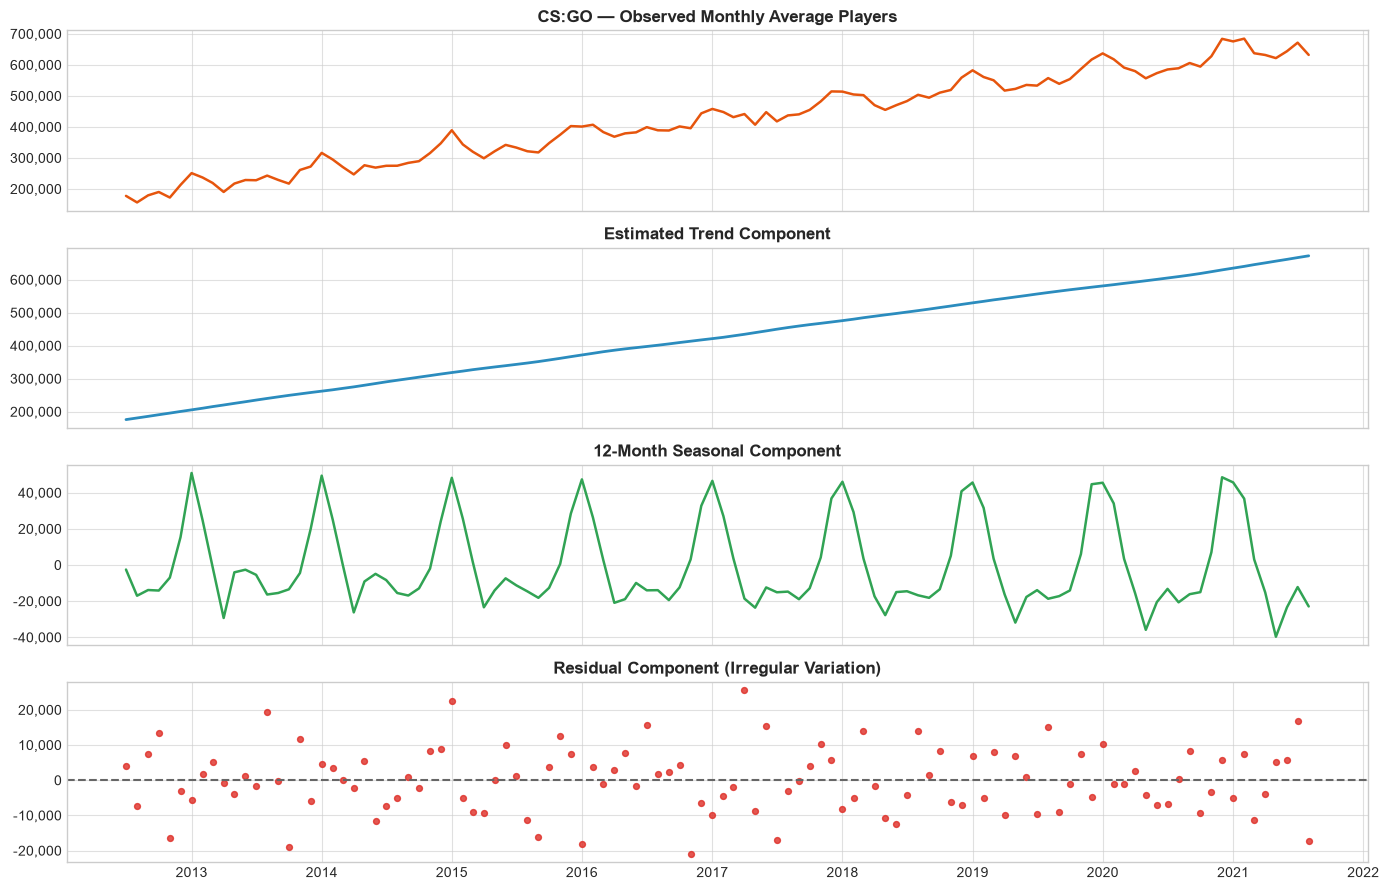

In [7]:
csgo_df = df_all[df_all["Game_Name"] == "Counter-Strike: Global Offensive"].sort_values("Month_Year")
csgo_series = pd.Series(csgo_df["Avg_players"].values, index=pd.to_datetime(csgo_df["Month_Year"]))

stl_result = decompose_time_series(csgo_series, period=12, method="stl")

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(csgo_series.index, stl_result["observed"], color="#e6550d", linewidth=1.8)
axes[0].set_title("CS:GO — Observed Monthly Average Players")

axes[1].plot(csgo_series.index, stl_result["trend"], color="#2b8cbe", linewidth=2.0)
axes[1].set_title("Estimated Trend Component")

axes[2].plot(csgo_series.index, stl_result["seasonal"], color="#31a354", linewidth=1.8)
axes[2].set_title("12-Month Seasonal Component")

axes[3].scatter(csgo_series.index, stl_result["resid"], color="#de2d26", s=18, alpha=0.8)
axes[3].axhline(0, color="#666666", linestyle="--")
axes[3].set_title("Residual Component (Irregular Variation)")

for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
axes[3].xaxis.set_major_locator(mdates.YearLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

## 8. Statistical Stationarity Tests (ADF & KPSS)

Stationarity is a fundamental requirement for statistical forecasting models (e.g. ARMA, SARIMA). We apply joint hypothesis testing:
- **Augmented Dickey-Fuller (ADF):** $H_0$ = Unit root is present (non-stationary). Rejection ($p < 0.05$) implies stationarity.
- **KPSS Test:** $H_0$ = Series is level/trend stationary. Rejection ($p < 0.05$) implies presence of a unit root (non-stationary).

Let's test both the raw series and the first-differenced series for all 7 titles:

In [8]:
stationarity_records = []

for game in sorted(df_all["Game_Name"].unique()):
    g_df = df_all[df_all["Game_Name"] == game].sort_values("Month_Year")
    raw_s = pd.Series(g_df["Avg_players"].values)
    diff_s = pd.Series(difference_series(raw_s, order=1, drop_na=True))

    # Test raw
    res_raw = check_stationarity(raw_s)
    # Test diff
    res_diff = check_stationarity(diff_s)

    stationarity_records.append({
        "Game Title": game,
        "Raw ADF Stat": f"{res_raw['adf']['test_statistic']:.3f}",
        "Raw ADF p-val": f"{res_raw['adf']['p_value']:.4f}",
        "Raw KPSS p-val": f"{res_raw['kpss']['p_value']:.4f}",
        "Raw Conclusion": "Non-Stationary" if not res_raw["is_stationary"] else "Stationary",
        "Diff(d=1) ADF Stat": f"{res_diff['adf']['test_statistic']:.3f}",
        "Diff(d=1) ADF p-val": f"{res_diff['adf']['p_value']:.4f}",
        "Diff(d=1) KPSS p-val": f"{res_diff['kpss']['p_value']:.4f}",
        "Diff Conclusion": "Stationary" if res_diff["adf"]["is_stationary"] else "Non-Stationary",
    })

stat_df = pd.DataFrame(stationarity_records)
display(stat_df)

                         Game Title Raw ADF Stat Raw ADF p-val Raw KPSS p-val  Raw Conclusion Diff(d=1) ADF Stat Diff(d=1) ADF p-val Diff(d=1) KPSS p-val Diff Conclusion
0  Counter-Strike: Global Offensive       -0.739        0.8365         0.0100  Non-Stationary             -8.480              0.0000               0.1000      Stationary
1                            Dota 2       -0.274        0.9291         0.0100  Non-Stationary             -9.658              0.0000               0.1000      Stationary
2                Grand Theft Auto V       -0.108        0.9486         0.0100  Non-Stationary             -7.094              0.0000               0.1000      Stationary
3                              Rust       -0.112        0.9483         0.0100  Non-Stationary             -8.726              0.0000               0.1000      Stationary
4                   Team Fortress 2       -0.917        0.7823         0.0209  Non-Stationary             -7.740              0.0000               0.1

## 9. Autocorrelation & Partial Autocorrelation (ACF / PACF)

We inspect the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) to identify memory structures and suitable initial lag specifications for Phase 3 SARIMA models:
- **Raw Series:** Slow linear decay in ACF confirms non-stationarity / unit root.
- **First-Differenced Series:** ACF cuts off quickly, exhibiting short-memory stationary behavior.
- **Seasonal Lags:** Peaks at lag 12 and lag 24 indicate seasonal persistence ($s=12$).

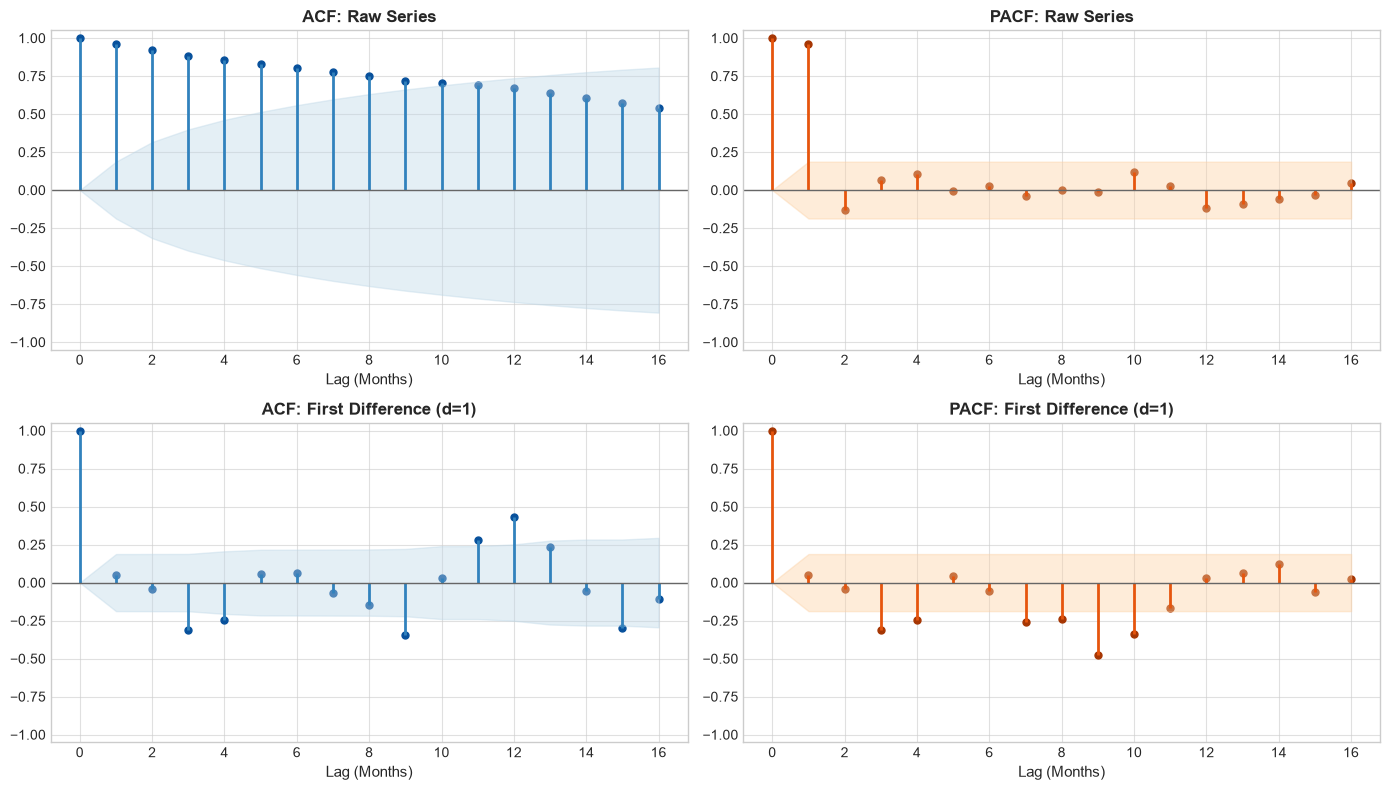

In [9]:
raw_s = pd.Series(csgo_df["Avg_players"].values)
diff_s = pd.Series(difference_series(raw_s, order=1, drop_na=True))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (label, s_data) in enumerate([("Raw Series", raw_s), ("First Difference (d=1)", diff_s)]):
    diag = compute_acf_pacf(s_data, nlags=16)
    lags = diag["lags"]

    # ACF
    ax_acf = axes[idx, 0]
    ax_acf.vlines(lags, [0], diag["acf"], color="#3182bd", linewidth=2.0)
    ax_acf.scatter(lags, diag["acf"], color="#08519c", s=25)
    ax_acf.fill_between(lags, diag["acf_confint"][:, 0] - diag["acf"], diag["acf_confint"][:, 1] - diag["acf"], color="#bdd7e7", alpha=0.4)
    ax_acf.axhline(0, color="#666666", linewidth=1.0)
    ax_acf.set_title(f"ACF: {label}")
    ax_acf.set_ylim(-1.05, 1.05)
    ax_acf.set_xlabel("Lag (Months)")

    # PACF
    ax_pacf = axes[idx, 1]
    ax_pacf.vlines(lags, [0], diag["pacf"], color="#e6550d", linewidth=2.0)
    ax_pacf.scatter(lags, diag["pacf"], color="#a63603", s=25)
    ax_pacf.fill_between(lags, diag["pacf_confint"][:, 0] - diag["pacf"], diag["pacf_confint"][:, 1] - diag["pacf"], color="#fdd0a2", alpha=0.4)
    ax_pacf.axhline(0, color="#666666", linewidth=1.0)
    ax_pacf.set_title(f"PACF: {label}")
    ax_pacf.set_ylim(-1.05, 1.05)
    ax_pacf.set_xlabel("Lag (Months)")

plt.tight_layout()
plt.show()

## 10. Leakage-Safe Preprocessing Pipeline

### Strict Anti-Leakage Protocol
In temporal forecasting, **data leakage occurs whenever information from the validation or test windows contaminates feature creation, scaling, or transformations**.

To strictly prevent lookahead bias:
1. **Splitting First:** Split into Train, Validation, and Test sets chronologically *before* calculating any distributional statistics.
2. **Train-Only Fitting:** Scalers (`MinMaxScaler`, `StandardScaler`, `RobustScaler`) and power transforms (`BoxCoxTransformer`, `LogTransformer`) fit their parameters (means, standard deviations, min/max, $\lambda$, offsets) **exclusively on the training partition**.
3. **Out-of-Sample Transformation & Inversion:** Validation and test observations are projected using parameters fitted on train, and can be inverted back to original level scales without distortion.

In [10]:
# 1. Chronological Train / Val / Test Split
split_result = train_val_test_split(csgo_df, val_months=12, test_months=12, date_col="Month_Year")
train_y = split_result.train["Avg_players"]
val_y = split_result.val["Avg_players"]
test_y = split_result.test["Avg_players"]

print("Split Summary:")
for k, v in split_result.summary().items():
    print(f"  {k}: {v}")

# 2. Scaler Verification: Fit ONLY on Train
scaler = TimeSeriesScaler(scaler_type="minmax")
scaler.fit(train_y)

train_scaled = scaler.transform(train_y)
val_scaled = scaler.transform(val_y)
test_scaled = scaler.transform(test_y)

print(f"\nScaler fitted min: {scaler.statistics_['data_min'][0]:,.1f}")
print(f"Scaler fitted max: {scaler.statistics_['data_max'][0]:,.1f}")
print(f"Train scaled min / max: {train_scaled.min():.3f} / {train_scaled.max():.3f}")
print(f"Test scaled max (exceeds 1.0 due to upward trend, proving zero lookahead leakage!): {test_scaled.max():.3f}")

# 3. Exact Inversion Check
test_reconstructed = scaler.inverse_transform(test_scaled)
assert np.allclose(test_reconstructed, test_y, rtol=1e-5)
print("Exact numerical inverse transform verified: True")

Split Summary:
  n_train: 86
  n_val: 12
  n_test: 12
  total_observations: 110
  train_start: 2012-07-01 00:00:00
  train_end: 2019-08-01 00:00:00
  val_start: 2019-09-01 00:00:00
  val_end: 2020-08-01 00:00:00
  test_start: 2020-09-01 00:00:00
  test_end: 2021-08-01 00:00:00

Scaler fitted min: 156,432.6
Scaler fitted max: 582,383.9
Train scaled min / max: 0.000 / 1.000
Test scaled max (exceeds 1.0 due to upward trend, proving zero lookahead leakage!): 1.240
Exact numerical inverse transform verified: True


### Box-Cox Power Transformation & Differencing Inversion
Let's verify the `BoxCoxTransformer` and `DifferencingTransformer` pipelines.

In [11]:
# Fit Box-Cox on train ONLY
bc_transformer = BoxCoxTransformer()
bc_transformer.fit(train_y)
print(f"Fitted Box-Cox lambda parameter (train only): {bc_transformer.lambda_:.4f}")

val_bc = bc_transformer.transform(val_y)
val_recovered = bc_transformer.inverse_transform(val_bc)
assert np.allclose(val_recovered, val_y, rtol=1e-5)
print("Box-Cox exact invertibility verified: True")

# Stateful Differencing Transformer with history buffer
diff_trans = DifferencingTransformer(order=1, seasonal_period=0)
diff_trans.fit(train_y)

# Differenced val series using boundary history
val_diff = difference_series(pd.concat([train_y.iloc[-1:], val_y]), order=1, drop_na=True)
val_level_recon = diff_trans.inverse_transform(val_diff)
assert np.allclose(val_level_recon, val_y, rtol=1e-5)
print("Differencing exact level reconstruction verified: True")

Fitted Box-Cox lambda parameter (train only): 0.8558
Box-Cox exact invertibility verified: True
Differencing exact level reconstruction verified: True


## 11. Conclusion & Transition to Phase 3

### Phase 2 Key Findings:
1. **Non-Stationarity:** Across all 7 games, both ADF and KPSS tests confirm the raw player trajectories are non-stationary unit-root processes ($d=1$).
2. **Heteroscedasticity:** Player fluctuations expand with increasing mean levels. Logarithmic or Box-Cox transformations effectively stabilize the conditional variance.
3. **Seasonality:** Strong 12-month calendar seasonality ($s=12$) is verified by STL decomposition and monthly deviation boxplots, peaking during Steam Summer Sales (June/July) and Winter Sales (December/January).
4. **Structural Breaks:** Significant regime shifts (CS:GO F2P in Dec 2018, COVID-19 in Mar 2020, Rust Twitch surge in Jan 2021) represent substantial challenges for purely autoregressive models, which will be benchmarked in Phase 3.
5. **Leakage-Safe Preprocessors:** All transformers and scalers are implemented with strict train-only fitting and verified exact inversion, ready for statistical modeling in Phase 3.

---
**Phase 2 Completed Successfully.** All unit tests in `tests/test_features.py` pass. Proceed to Phase 3 (Statistical Forecasting).